# AO1 Clase 2 – Limpieza, Transformación y Análisis Exploratorio de Datos con LLMs

**Alumno:** Cristian Sombra  
**Materia:** Minería de Datos  
**Actividad Obligatoria – Clase 2**

## Objetivo
Aplicar identificación de tipos de datos, limpieza, transformación y análisis exploratorio sobre un dataset de empleados, integrando además el uso de un LLM como apoyo metodológico.

---


## 1. Librerías y construcción del dataset

Se parte del dataset propuesto en la consigna. Luego se realiza una inspección inicial para detectar problemas de calidad de datos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

# Mostrar más columnas si hiciera falta
pd.set_option("display.max_columns", None)

# Dataset base de la consigna
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoría": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


## 2. Observación inicial del conjunto de datos

Se revisa estructura, tipos de datos, estadísticas básicas, valores faltantes, duplicados e inconsistencias visibles.


In [2]:
print("Información general del dataset:\n")
df.info()

print("\nResumen descriptivo:")
display(df.describe(include="all"))

print("\nValores faltantes por columna:")
display(df.isnull().sum().to_frame("faltantes"))

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nRegistros con edad negativa:")
display(df[df["Edad"] < 0])

print("\nValores únicos de Estado:")
display(pd.DataFrame({"Estado": df["Estado"].unique()}))

Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoría        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 412.0+ bytes

Resumen descriptivo:


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
count,5.000000,5,5.00000,5,4.000000,5,5
unique,NaN,5,NaN,3,NaN,3,3
top,NaN,Juan,NaN,Licenciado,NaN,Junior,Activo
freq,NaN,1,NaN,2,NaN,2,2
mean,3.000000,NaN,25.80000,NaN,91250.000000,NaN,NaN
std,1.581139,NaN,30.84153,NaN,72614.851557,NaN,NaN
min,1.000000,NaN,-28.00000,NaN,50000.000000,NaN,NaN
25%,2.000000,NaN,32.00000,NaN,53750.000000,NaN,NaN
50%,3.000000,NaN,35.00000,NaN,57500.000000,NaN,NaN
75%,4.000000,NaN,40.00000,NaN,95000.000000,NaN,NaN



Valores faltantes por columna:


,faltantes
ID,0
Nombre,0
Edad,0
Nivel_Educativo,0
Salario,1
Categoría,0
Estado,0



Filas duplicadas: 0

Registros con edad negativa:


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
1,2,María,-28,Ingeniero,60000.0,Senior,ACTIVO



Valores únicos de Estado:


,Estado
0,Activo
1,ACTIVO
2,Inactivo


## 3. Clasificación de variables y criterio de manejo

| Variable | Tipo | Criterio de manejo |
|---|---|---|
| ID | Numérico entero (identificador) | No se usa para análisis predictivo porque solo identifica registros. |
| Nombre | Categórico nominal | Se mantiene como referencia, pero no se codifica para el análisis principal. |
| Edad | Numérico discreto | Debe validarse por posibles errores de carga, como valores negativos. |
| Nivel_Educativo | Categórico ordinal | Tiene jerarquía académica, por lo que se justifica codificación ordinal. |
| Salario | Numérico continuo | Requiere tratamiento de faltantes, detección de outliers y normalización. |
| Categoría | Categórico ordinal | Se asume orden jerárquico laboral: Junior < Senior < Manager. Por eso se usa codificación ordinal. |
| Estado | Categórico nominal/binario | Debe unificarse por inconsistencias de escritura y luego codificarse en forma binaria. |

### Justificación general
Las decisiones de limpieza y transformación impactan directamente en la calidad del análisis. Variables mal tipadas, inconsistentes o con outliers no tratados pueden distorsionar estadísticas, correlaciones y futuros modelos.


## 4. Limpieza de datos

### Problemas detectados
1. **Edad negativa** en un registro.
2. **Valor faltante** en `Salario`.
3. **Inconsistencia** en la variable `Estado` (`Activo` / `ACTIVO`).
4. **Posible outlier** en `Salario` (200000).

### Criterio aplicado
- La edad negativa se corrige con valor absoluto porque es razonable interpretar que hubo error de carga del signo.
- El salario faltante se reemplaza con la **mediana**, porque en conjuntos pequeños y con posible asimetría es más robusta que la media.
- `Estado` se estandariza para evitar duplicación semántica de categorías.


In [3]:
# Copia de trabajo
df_limpio = df.copy()

# 1) Corregir edad negativa
df_limpio["Edad"] = df_limpio["Edad"].abs()

# 2) Imputar salario faltante con la mediana
mediana_salario = df_limpio["Salario"].median()
df_limpio["Salario"] = df_limpio["Salario"].fillna(mediana_salario)

# 3) Unificar la variable Estado
df_limpio["Estado"] = df_limpio["Estado"].str.strip().str.capitalize()

df_limpio

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


## 5. Detección y tratamiento de outliers en `Salario`

Se utiliza el método del **rango intercuartílico (IQR)** porque:
- es simple,
- es interpretable,
- y fue sugerido explícitamente en clase como criterio válido.

### Justificación de la decisión
En este caso se **elimina** el registro outlier porque:
- el dataset es pequeño,
- el valor `200000` se aleja mucho del resto,
- y podría distorsionar tanto la normalización como el análisis exploratorio.

Aun así, esta decisión debe contextualizarse: en un dataset real, antes de eliminar un caso extremo habría que verificar si se trata de un error o de un valor legítimo de negocio.


In [4]:
Q1 = df_limpio["Salario"].quantile(0.25)
Q3 = df_limpio["Salario"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers = df_limpio[(df_limpio["Salario"] < limite_inferior) | (df_limpio["Salario"] > limite_superior)]

print("\nRegistros detectados como outliers:")
display(outliers)

# Eliminar outliers salariales
df_limpio = df_limpio[(df_limpio["Salario"] >= limite_inferior) & (df_limpio["Salario"] <= limite_superior)].copy()

print("Dataset luego de eliminar outliers:")
display(df_limpio)

Q1: 55000.0
Q3: 60000.0
IQR: 5000.0
Límite inferior: 47500.0
Límite superior: 67500.0

Registros detectados como outliers:


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


Dataset luego de eliminar outliers:


,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,María,28,Ingeniero,60000.0,Senior,Activo
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo


## 6. Transformación de variables

### Decisiones de transformación
- **Nivel_Educativo**: codificación ordinal por jerarquía académica.
- **Categoría**: codificación ordinal por jerarquía laboral asumida.
- **Estado**: codificación binaria porque solo quedan dos valores.
- **Salario**: normalización Min-Max para llevarlo a una escala comparable.
- **Anios_Hasta_Jubilacion**: nueva variable derivada de la edad, calculada como `65 - Edad`.


In [5]:
# Codificación ordinal de Nivel_Educativo
encoder_nivel = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df_limpio["Nivel_Cod"] = encoder_nivel.fit_transform(df_limpio[["Nivel_Educativo"]])

# Codificación ordinal de Categoría
encoder_categoria = OrdinalEncoder(categories=[["Junior", "Senior", "Manager"]])
df_limpio["Categoria_Cod"] = encoder_categoria.fit_transform(df_limpio[["Categoría"]])

# Codificación binaria de Estado
df_limpio["Estado_Cod"] = df_limpio["Estado"].map({"Activo": 1, "Inactivo": 0})

# Normalización de salario
scaler = MinMaxScaler()
df_limpio["Salario_Normalizado"] = scaler.fit_transform(df_limpio[["Salario"]])

# Nueva variable
df_limpio["Anios_Hasta_Jubilacion"] = 65 - df_limpio["Edad"]

df_limpio

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoría,Estado,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
0,1,Juan,32,Licenciado,50000.0,Junior,Activo,0.0,0.0,1,0.00,33
1,2,María,28,Ingeniero,60000.0,Senior,Activo,1.0,1.0,1,1.00,37
2,3,Pedro,40,Doctorado,57500.0,Senior,Inactivo,2.0,1.0,0,0.75,25
3,4,Ana,35,Licenciado,55000.0,Junior,Activo,0.0,0.0,1,0.50,30


## 7. Estadísticas descriptivas y correlación

Se realiza un resumen del dataset procesado para observar medidas básicas y relaciones lineales entre variables numéricas.


In [6]:
print("Estadísticas descriptivas del dataset procesado:")
display(df_limpio.describe())

columnas_corr = ["Edad", "Salario", "Nivel_Cod", "Categoria_Cod", "Estado_Cod", "Anios_Hasta_Jubilacion"]
corr = df_limpio[columnas_corr].corr()

print("Matriz de correlación:")
display(corr)

Estadísticas descriptivas del dataset procesado:


,ID,Edad,Salario,Nivel_Cod,Categoria_Cod,Estado_Cod,Salario_Normalizado,Anios_Hasta_Jubilacion
count,4.000000,4.000000,4.000000,4.000000,4.00000,4.00,4.000000,4.000000
mean,2.500000,33.750000,55625.000000,0.750000,0.50000,0.75,0.562500,31.250000
std,1.290994,5.057997,4269.562819,0.957427,0.57735,0.50,0.426956,5.057997
min,1.000000,28.000000,50000.000000,0.000000,0.00000,0.00,0.000000,25.000000
25%,1.750000,31.000000,53750.000000,0.000000,0.00000,0.75,0.375000,28.750000
50%,2.500000,33.500000,56250.000000,0.500000,0.50000,1.00,0.625000,31.500000
75%,3.250000,36.250000,58125.000000,1.250000,1.00000,1.00,0.812500,34.000000
max,4.000000,40.000000,60000.000000,2.000000,1.00000,1.00,1.000000,37.000000


Matriz de correlación:


,Edad,Salario,Nivel_Cod,Categoria_Cod,Estado_Cod,Anios_Hasta_Jubilacion
Edad,1.000000,-0.067530,0.464620,0.057073,-0.823778,-1.000000
Salario,-0.067530,1.000000,0.662541,0.845154,-0.292770,0.067530
Nivel_Cod,0.464620,0.662541,1.000000,0.904534,-0.870388,-0.464620
Categoria_Cod,0.057073,0.845154,0.904534,1.000000,-0.577350,-0.057073
Estado_Cod,-0.823778,-0.292770,-0.870388,-0.577350,1.000000,0.823778
Anios_Hasta_Jubilacion,-1.000000,0.067530,-0.464620,-0.057073,0.823778,1.000000


## 8. Análisis exploratorio de datos (EDA)

Se incluyen al menos dos visualizaciones, con interpretación breve.

### Visualización 1: Histograma de `Salario`
Permite ver cómo se distribuyen los salarios luego de la limpieza.

### Visualización 2: Boxplot de `Salario`
Sirve para verificar si todavía quedan valores atípicos tras aplicar IQR.

### Visualización 3: Dispersión entre `Edad` y `Salario`
Ayuda a observar si hay una relación visible entre ambas variables y cómo se distribuyen según `Estado`.


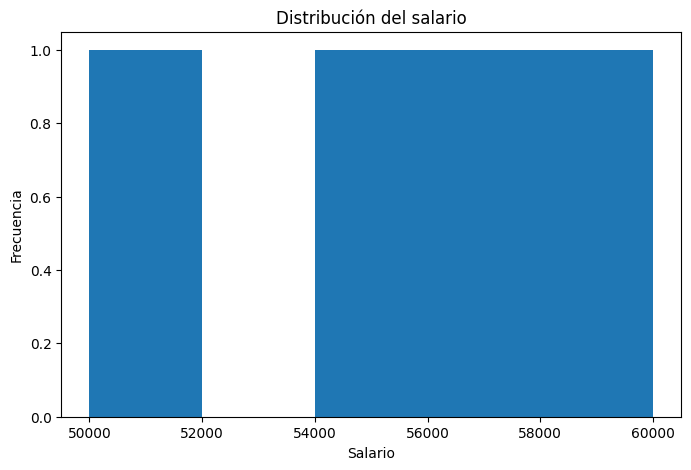

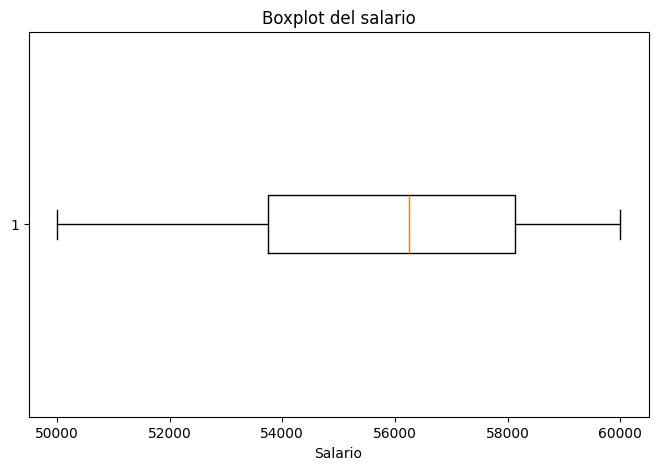

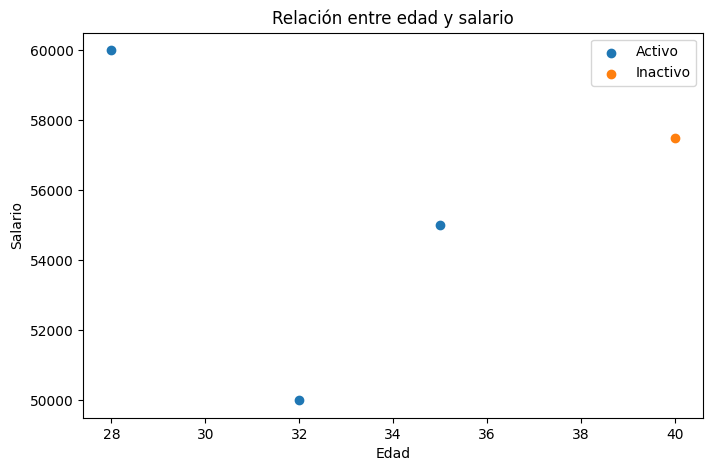

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df_limpio["Salario"], bins=5)
plt.title("Distribución del salario")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df_limpio["Salario"], vert=False)
plt.title("Boxplot del salario")
plt.xlabel("Salario")
plt.show()

plt.figure(figsize=(8, 5))
for estado, grupo in df_limpio.groupby("Estado"):
    plt.scatter(grupo["Edad"], grupo["Salario"], label=estado)

plt.title("Relación entre edad y salario")
plt.xlabel("Edad")
plt.ylabel("Salario")
plt.legend()
plt.show()

## 9. Interpretación de resultados

### Hallazgos principales
- Se detectó y corrigió una **edad negativa**, lo que evitó que la variable quedara con un valor inválido.
- Se imputó un **salario faltante** con la mediana, una medida robusta frente a valores extremos.
- Se unificó la variable **Estado**, corrigiendo inconsistencias de escritura.
- Se detectó un **outlier** claro en `Salario` y se decidió eliminarlo para no distorsionar el análisis.
- Luego de la limpieza, los salarios quedaron concentrados en un rango mucho más homogéneo.
- El boxplot confirma que, tras eliminar el outlier, no se observan valores extremos evidentes en el conjunto final.
- El gráfico de dispersión no muestra una relación lineal fuerte entre edad y salario, aunque el dataset es demasiado pequeño para sacar conclusiones firmes.
- La correlación entre `Edad` y `Anios_Hasta_Jubilacion` es de `-1`, lo cual es esperable porque una variable se deriva directamente de la otra.

### Limitación
El dataset final queda con muy pocos registros, por lo que cualquier conclusión exploratoria debe considerarse solo ilustrativa y no generalizable.


## 10. Uso de LLM

### Prompt 1
**"¿Qué método simple puedo usar en Python para detectar valores atípicos en una columna numérica y cuándo conviene eliminar esos registros?"**

**Síntesis de la respuesta**  
La respuesta recomendó el método IQR como una forma sencilla de detectar outliers a partir de cuartiles y del rango intercuartílico. También indicó que eliminar registros puede ser razonable cuando el valor extremo parece error o distorsiona fuertemente el análisis, aunque siempre debe justificarse con contexto.

**Validación personal**  
Se tomó esta sugerencia porque coincide con lo visto en clase y porque el valor de salario `200000` se aleja claramente del resto. Sin embargo, se aclara que en un problema real primero debería verificarse si ese valor es legítimo antes de eliminarlo.

---

### Prompt 2
**"¿Qué visualizaciones son adecuadas para explorar un dataset pequeño con variables como edad, salario y estado?"**

**Síntesis de la respuesta**  
El LLM sugirió usar histograma para distribución, boxplot para dispersión y outliers, y gráfico de dispersión para explorar relaciones entre variables numéricas. También señaló que, con pocos datos, las conclusiones deben ser prudentes.

**Validación personal**  
Las sugerencias fueron útiles porque encajan con el objetivo del EDA pedido en la actividad. Se eligieron esos gráficos porque permiten una lectura rápida y clara del comportamiento del dataset sin agregar complejidad innecesaria.


## 11. Conclusión

En esta actividad se aplicaron las principales etapas del preprocesamiento de datos: identificación de tipos, limpieza, transformación y análisis exploratorio.  
Las decisiones tomadas fueron justificadas en función del problema y del tamaño del dataset. Además, se integró el uso de un LLM como apoyo metodológico, pero manteniendo validación propia sobre las respuestas obtenidas.

El resultado es un notebook reproducible, ordenado y alineado con los criterios de evaluación de la consigna.
